<a href="https://colab.research.google.com/github/Huang-stat/Computer-Labs/blob/main/AKHU_CS_Lab4_JSON_Pickle_MultipleRegression_2026_05_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS Lab 4 - JSON, Pickle, and Multiple Regression Persistence

**Date:** Thursday, 14 May 2026, 16:00  
**Location:** Comp. Lab 1  
**Topic:** Advanced object persistence using JSON and pickle with a package-based multiple-regression workflow

This notebook demonstrates how these files work together:

| File type | Role in this lab |
|---|---|
| `.ipynb` or `.py` | Stores Python instructions. |
| `.csv` | Stores raw table data. |
| `.json` | Stores readable configuration, reports, run history, and new prediction inputs. |
| `.pkl` | Stores a trusted Python model object or artifact. |

Main idea:

> A notebook or script stores the instructions. JSON and pickle files store settings, results, prediction inputs, and model state that survive after Python stops.

## 1. Colab versus Visual Studio Code / Visual Studio folders

The same Python commands can load files in Colab and Visual Studio Code, but the folders are different.

### Colab method

Common Colab locations:

```text
/content
/content/data
/content/drive/MyDrive/AKHU_labs
```

Fast demonstration method:

1. Open the folder icon on the left in Colab.
2. Upload the CSV, JSON, and pickle files.
3. They normally appear in `/content`.

Google Drive method:

```python
from google.colab import drive
drive.mount('/content/drive')
```

Then place files in:

```text
MyDrive/AKHU_labs
```

### Visual Studio Code / Visual Studio method

Recommended project structure:

```text
Lab4_Project/
  AKHU_CS_Lab4_Object_Persistence_JSON_Pickle_MultipleRegression_COLAB_VSCODE_2026_05_14.ipynb
  data/
    AKHU_lab4_student_scores_regression.csv
    AKHU_lab4_regression_config.json
    AKHU_lab4_new_students_for_prediction.json
  outputs/
  models/
  assets/
```

Install packages in the terminal if needed:

```bash
python -m pip install pandas numpy scikit-learn matplotlib
```

The most useful diagnostic command is:

```python
from pathlib import Path
print(Path.cwd())
```

In [1]:
from pathlib import Path
import json
import pickle
import math
import sys

print("Current working directory:", Path.cwd())

# These folders let the same notebook work in Colab and VS Code.
CANDIDATE_DIRS = [
    Path("data"),                              # VS Code recommended folder
    Path("."),                                 # same folder as notebook
    Path("/content"),                          # Colab direct upload folder
    Path("/content/data"),                     # Colab organized data folder
    Path("/content/drive/MyDrive/AKHU_labs"),  # Colab Google Drive folder
]

MODEL_DIRS = [
    Path("models"),
    Path("."),
    Path("/content"),
    Path("/content/models"),
    Path("/content/drive/MyDrive/AKHU_labs"),
]

OUTPUT_DIR = Path("outputs")
MODEL_OUTPUT_DIR = Path("models")
ASSETS_DIR = Path("assets")
for folder in [OUTPUT_DIR, MODEL_OUTPUT_DIR, ASSETS_DIR]:
    folder.mkdir(exist_ok=True)


def find_file(filename, folders=CANDIDATE_DIRS):
    """Search common Colab and VS Code folders for a file."""
    print("Searching for:", filename)
    for folder in folders:
        candidate = folder / filename
        print("  checking:", candidate)
        if candidate.exists():
            print("Found:", candidate)
            return candidate
    searched = chr(10).join(str(folder) for folder in folders)
    raise FileNotFoundError(f"Could not find {filename}. Searched:\n{searched}")

Current working directory: /content


## 2. Open JSON files: Colab method and Visual Studio method

JSON files are text files. Open them in text mode using `'r'` and an encoding.

Colab JSON path examples:

```python
Path('/content/AKHU_lab4_regression_config.json')
Path('/content/drive/MyDrive/AKHU_labs/AKHU_lab4_regression_config.json')
```

Visual Studio JSON path example:

```python
Path('data') / 'AKHU_lab4_regression_config.json'
```

In [2]:
def open_json_colab_style(filename):
    """Colab-focused JSON loader. It checks /content and Google Drive."""
    colab_dirs = [
        Path("/content"),
        Path("/content/data"),
        Path("/content/drive/MyDrive/AKHU_labs"),
    ]
    path = find_file(filename, folders=colab_dirs)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def open_json_vscode_style(filename):
    """VS-Code-focused JSON loader. It expects a data/ folder in the project."""
    path = Path("data") / filename
    print("VS Code expected path:", path.resolve())
    if not path.exists():
        print("This path does not exist here. In VS Code, open the project folder that contains data/.")
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

# Robust method used by the rest of this notebook:
config_path = find_file("AKHU_lab4_regression_config.json")
with config_path.open("r", encoding="utf-8") as f:
    config = json.load(f)

print("Loaded JSON config:")
print(json.dumps(config, indent=4))

Searching for: AKHU_lab4_regression_config.json
  checking: data/AKHU_lab4_regression_config.json
  checking: AKHU_lab4_regression_config.json
Found: AKHU_lab4_regression_config.json
Loaded JSON config:
{
    "lab": "CS Lab 4 - JSON and Pickle Persistence for Multiple Regression",
    "created_for": "May 14 computer lab",
    "data_file": "AKHU_lab4_student_scores_regression.csv",
    "target": "final_score",
    "features": [
        "hours_studied",
        "quiz_average",
        "attendance_rate",
        "assignments_submitted"
    ],
    "train_rows": 24,
    "model_type": "sklearn.linear_model.LinearRegression",
    "metrics": [
        "MAE",
        "RMSE",
        "R2"
    ],
    "output_json_report": "AKHU_lab4_regression_report.json",
    "output_pickle_artifact": "AKHU_lab4_regression_artifact.pkl",
    "security_note": "Only load pickle files from trusted sources. JSON is safer for sharing reports and configuration."
}


## 3. Open pickle files: Colab method and Visual Studio method

Pickle files are binary files. Open them in binary mode using `'rb'`, not text mode.

Important warning:

> Only unpickle files that came from this trusted lab bundle or from your own notebook run. Never unpickle unknown files from the internet.

Colab pickle path examples:

```python
Path('/content/AKHU_lab4_regression_artifact.pkl')
Path('/content/drive/MyDrive/AKHU_labs/AKHU_lab4_regression_artifact.pkl')
```

Visual Studio pickle path example:

```python
Path('models') / 'AKHU_lab4_regression_artifact.pkl'
```

This notebook creates a new pickle artifact later. If a pickle file already exists, the helper below can load it.

In [16]:
def open_pickle_colab_style(filename):
    """Colab-focused pickle loader. Only use this with trusted pickle files."""
    colab_dirs = [
        Path("/content"),
        Path("/content/models"),
        Path("/content/drive/MyDrive/AKHU_labs"),
    ]
    path = find_file(filename, folders=colab_dirs)
    with path.open("rb") as f:
        return pickle.load(f)


def open_pickle_vscode_style(filename):
    """VS-Code-focused pickle loader. It expects a models/ folder in the project."""
    path = Path("models") / filename
    print("VS Code expected path:", path.resolve())
    if not path.exists():
        print("This path does not exist yet. The notebook will create a pickle artifact later.")
        return None
    with path.open("rb") as f:
        return pickle.load(f)

## 4. Import packages for package-based multiple regression

This lab uses package-based multiple regression rather than a hand-coded one-variable model.

Packages used:

- `pandas`: table data
- `numpy`: arrays and optional QR decomposition
- `scikit-learn`: `LinearRegression` and metrics
- `matplotlib`: result plots

In [4]:
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
except ImportError as exc:
    print("A required package is missing.")
    print("In VS Code, run: python -m pip install pandas numpy scikit-learn matplotlib")
    raise exc

print("Packages imported successfully.")

Packages imported successfully.


## 5. Load the CSV data

The JSON config tells Python which CSV file to load. This is useful because changing the data file or feature list can be done in JSON without rewriting the main notebook code.

In [5]:
csv_path = find_file(config["data_file"])
df = pd.read_csv(csv_path)

print("CSV path:", csv_path)
print("Shape:", df.shape)
df.head()

Searching for: AKHU_lab4_student_scores_regression.csv
  checking: data/AKHU_lab4_student_scores_regression.csv
  checking: AKHU_lab4_student_scores_regression.csv
Found: AKHU_lab4_student_scores_regression.csv
CSV path: AKHU_lab4_student_scores_regression.csv
Shape: (30, 7)


,student_id,hours_studied,quiz_average,attendance_rate,assignments_submitted,participation_score,final_score
0,S01,1.2,52,0.58,4,45,50
1,S02,1.6,55,0.62,4,48,53
2,S03,2.0,58,0.65,5,52,57
3,S04,2.2,60,0.67,5,55,60
4,S05,2.5,63,0.70,6,58,64


## 6. Select multiple predictors and the target

Multiple regression uses more than one predictor.

Target:

```text
final_score
```

Predictors:

- `hours_studied`
- `quiz_average`
- `attendance_rate`
- `assignments_submitted`

The model equation is:

$$
\hat{y} = \hat{eta}_0 + \hat{eta}_1 x_1 + \hat{eta}_2 x_2 + \hat{eta}_3 x_3 + \hat{eta}_4 x_4.
$$

In [6]:
features = config["features"]
target = config["target"]
train_rows = int(config["train_rows"])

print("Target column:", target)
print("Predictor columns:", features)

train_df = df.iloc[:train_rows].copy()
test_df = df.iloc[train_rows:].copy()

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
X_train.head()

Target column: final_score
Predictor columns: ['hours_studied', 'quiz_average', 'attendance_rate', 'assignments_submitted']
Train rows: 24
Test rows: 6


,hours_studied,quiz_average,attendance_rate,assignments_submitted
0,1.2,52,0.58,4
1,1.6,55,0.62,4
2,2.0,58,0.65,5
3,2.2,60,0.67,5
4,2.5,63,0.70,6


## 7. Fit a mean baseline and package multiple regression

The baseline predicts the average training score for every test student.

The multiple-regression model uses `sklearn.linear_model.LinearRegression`.

In [7]:
# Mean baseline
baseline_prediction = float(y_train.mean())
y_pred_baseline = np.full(shape=len(y_test), fill_value=baseline_prediction)

# Package multiple regression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_regression = model.predict(X_test)

print("Mean baseline prediction:", round(baseline_prediction, 3))
print("Regression intercept:", round(float(model.intercept_), 3))
print("Regression coefficients:")
for name, coef in zip(features, model.coef_):
    print(f"  {name}: {coef:.4f}")

Mean baseline prediction: 71.833
Regression intercept: 8.06
Regression coefficients:
  hours_studied: 5.4281
  quiz_average: 0.6032
  attendance_rate: 1.8210
  assignments_submitted: 0.4871


## 8. Compare model performance

Metrics:

- **MAE:** mean absolute error. Smaller is better.
- **RMSE:** root mean squared error. Smaller is better.
- **R2:** coefficient of determination. Larger is better.

In [8]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }

metrics_baseline = regression_metrics(y_test, y_pred_baseline)
metrics_regression = regression_metrics(y_test, y_pred_regression)

comparison = pd.DataFrame([
    {"model": "Mean baseline", **metrics_baseline},
    {"model": "Package multiple regression", **metrics_regression},
])
comparison

,model,MAE,RMSE,R2
0,Mean baseline,13.50000,15.489244,-0.048561
1,Package multiple regression,0.97543,1.117684,0.994540


## 9. Plot modeling results

These are result plots for the regression analysis.

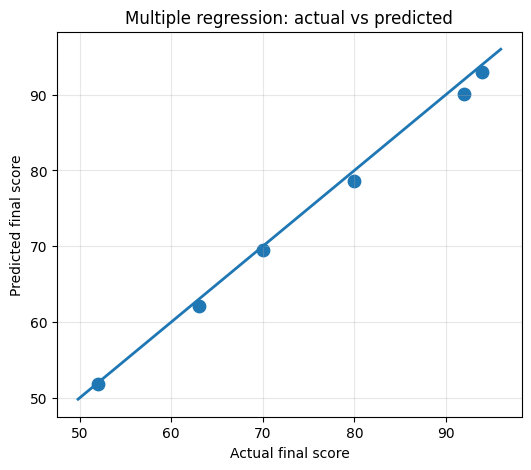

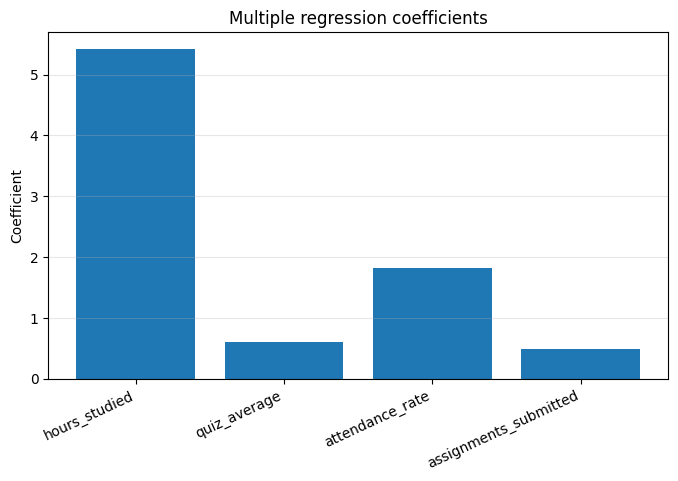

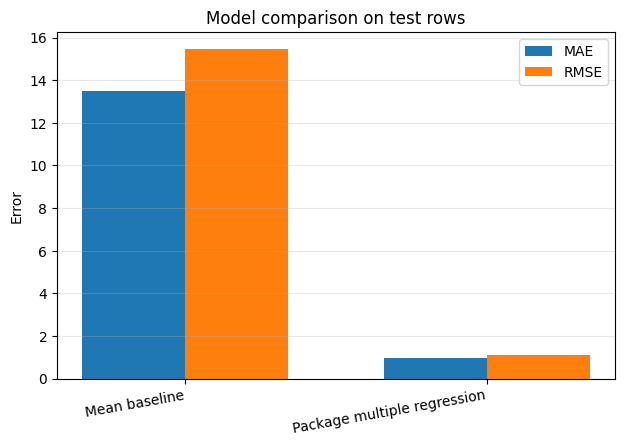

In [9]:
# Plot 1: actual vs predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_regression, s=80)
low = min(y_test.min(), y_pred_regression.min()) - 2
high = max(y_test.max(), y_pred_regression.max()) + 2
plt.plot([low, high], [low, high], linewidth=2)
plt.xlabel("Actual final score")
plt.ylabel("Predicted final score")
plt.title("Multiple regression: actual vs predicted")
plt.grid(True, alpha=0.3)
plt.savefig(ASSETS_DIR / "actual_vs_predicted_multiple_regression.png", dpi=160, bbox_inches="tight")
plt.show()

# Plot 2: coefficients
coef_table = pd.DataFrame({"feature": features, "coefficient": model.coef_})
plt.figure(figsize=(8, 4.5))
plt.bar(coef_table["feature"], coef_table["coefficient"])
plt.ylabel("Coefficient")
plt.title("Multiple regression coefficients")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.savefig(ASSETS_DIR / "multiple_regression_coefficients.png", dpi=160, bbox_inches="tight")
plt.show()

# Plot 3: model comparison
x = np.arange(len(comparison))
width = 0.34
plt.figure(figsize=(7.2, 4.5))
plt.bar(x - width/2, comparison["MAE"], width, label="MAE")
plt.bar(x + width/2, comparison["RMSE"], width, label="RMSE")
plt.xticks(x, comparison["model"], rotation=10, ha="right")
plt.ylabel("Error")
plt.title("Model comparison on test rows")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.savefig(ASSETS_DIR / "model_comparison_multiple_regression.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Save a readable JSON regression report

A JSON report helps modeling and data analysis because it preserves the model result after the notebook stops.

The JSON report stores simple, readable information:

- target and feature names;
- intercept and coefficients;
- baseline metrics;
- multiple-regression metrics;
- test predictions.

JSON is the right format for this report because it can be opened in a text editor.

In [10]:
coefficients = {name: float(coef) for name, coef in zip(features, model.coef_)}

prediction_rows = []
for student_id, actual, predicted in zip(test_df["student_id"], y_test, y_pred_regression):
    prediction_rows.append({
        "student_id": student_id,
        "actual_final_score": float(actual),
        "predicted_final_score": round(float(predicted), 3),
        "residual": round(float(actual - predicted), 3),
    })

report = {
    "report_type": "multiple_regression_json_report",
    "important_message": "This JSON file stores readable model facts and results, not the trained Python object.",
    "why_json_helps": [
        "The feature list and target can be recorded without editing the notebook.",
        "The coefficients, metrics, and predictions remain available after the Python session ends.",
        "The report can be opened in a text editor or shared with non-Python tools.",
    ],
    "model_type": config["model_type"],
    "data_file": config["data_file"],
    "target": target,
    "features": features,
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "intercept": float(model.intercept_),
    "coefficients": coefficients,
    "baseline_metrics": {k: round(v, 4) for k, v in metrics_baseline.items()},
    "multiple_regression_metrics": {k: round(v, 4) for k, v in metrics_regression.items()},
    "test_predictions": prediction_rows,
    "json_vs_pickle_note": "JSON is readable and portable. Pickle is Python-specific and should only be loaded from trusted sources.",
}

report_path = OUTPUT_DIR / "AKHU_lab4_regression_report_from_notebook.json"
with report_path.open("w", encoding="utf-8") as f:
    json.dump(report, f, indent=4)

print("Saved JSON report to:", report_path)
print(json.dumps(report, indent=4)[:1200])

Saved JSON report to: outputs/AKHU_lab4_regression_report_from_notebook.json
{
    "report_type": "multiple_regression_json_report",
    "important_message": "This JSON file stores readable model facts and results, not the trained Python object.",
    "why_json_helps": [
        "The feature list and target can be recorded without editing the notebook.",
        "The coefficients, metrics, and predictions remain available after the Python session ends.",
        "The report can be opened in a text editor or shared with non-Python tools."
    ],
    "model_type": "sklearn.linear_model.LinearRegression",
    "data_file": "AKHU_lab4_student_scores_regression.csv",
    "target": "final_score",
    "features": [
        "hours_studied",
        "quiz_average",
        "attendance_rate",
        "assignments_submitted"
    ],
    "train_rows": 24,
    "test_rows": 6,
    "intercept": 8.060076298612742,
    "coefficients": {
        "hours_studied": 5.428136744104028,
        "quiz_average": 

## 11. Why JSON cannot directly save the trained model object

JSON is good for dictionaries, lists, strings, numbers, booleans, and `null`.

A trained `LinearRegression` object contains Python-specific object state and methods. JSON does not know how to represent that object.

In [11]:
try:
    json.dumps(model)
except TypeError as exc:
    print("JSON cannot save the trained model object directly.")
    print("Error message:", exc)

JSON cannot save the trained model object directly.
Error message: Object of type LinearRegression is not JSON serializable


## 12. Save a trusted pickle model artifact

Pickle helps modeling because it can restore the fitted Python model object.

This means a later notebook or script can make predictions without refitting the model.

Security rule:

> Only unpickle files from this trusted lab bundle or files created by your own code.

In [12]:
artifact = {
    "artifact_type": "trusted_python_pickle_model_artifact",
    "warning": "Only unpickle this file if it came from the trusted lab bundle or your own notebook run.",
    "why_pickle_helps": "Pickle restores the trained Python model object, so Python can make new predictions without refitting.",
    "model": model,
    "features": features,
    "target": target,
    "metrics": metrics_regression,
    "coefficients": coefficients,
    "intercept": float(model.intercept_),
}

pickle_path = MODEL_OUTPUT_DIR / config["output_pickle_artifact"]
with pickle_path.open("wb") as f:
    pickle.dump(artifact, f)

print("Saved trusted pickle artifact to:", pickle_path)
print("Pickle files are binary. First 80 bytes:")
print(pickle_path.read_bytes()[:80])

Saved trusted pickle artifact to: models/AKHU_lab4_regression_artifact.pkl
Pickle files are binary. First 80 bytes:
b'\x80\x04\x95\x8b\x04\x00\x00\x00\x00\x00\x00}\x94(\x8c\rartifact_type\x94\x8c$trusted_python_pickle_model_artifact\x94\x8c\x07warning\x94\x8c'


## 13. Load the JSON report and pickle artifact

This is the persistence test:

- JSON reloads readable facts and metrics.
- Pickle reloads the trusted Python model object.

In [13]:
with report_path.open("r", encoding="utf-8") as f:
    loaded_report = json.load(f)

with pickle_path.open("rb") as f:
    loaded_artifact = pickle.load(f)

loaded_model = loaded_artifact["model"]
loaded_features = loaded_artifact["features"]

print("Loaded JSON report type:", loaded_report["report_type"])
print("Loaded JSON features:", loaded_report["features"])
print("Loaded pickle warning:", loaded_artifact["warning"])
print("Loaded pickle features:", loaded_features)

Loaded JSON report type: multiple_regression_json_report
Loaded JSON features: ['hours_studied', 'quiz_average', 'attendance_rate', 'assignments_submitted']
Loaded pickle warning: Only unpickle this file if it came from the trusted lab bundle or your own notebook run.
Loaded pickle features: ['hours_studied', 'quiz_average', 'attendance_rate', 'assignments_submitted']


## 14. Use a JSON input file for new predictions

This example shows why JSON and pickle are useful together:

1. JSON stores new student records.
2. Pickle restores the trained model.
3. Python uses the loaded model to predict.
4. JSON saves the prediction output.

In [14]:
new_students_path = find_file("AKHU_lab4_new_students_for_prediction.json")
with new_students_path.open("r", encoding="utf-8") as f:
    new_students = json.load(f)

new_df = pd.DataFrame(new_students["records"])
new_predictions = loaded_model.predict(new_df[loaded_features])

new_prediction_report = {
    "prediction_report_type": "new_student_predictions_from_loaded_pickle_model",
    "source_pickle_model": str(pickle_path),
    "input_json": str(new_students_path),
    "predictions": [
        {"student_id": sid, "predicted_final_score": round(float(pred), 3)}
        for sid, pred in zip(new_df["student_id"], new_predictions)
    ],
}

new_pred_path = OUTPUT_DIR / "AKHU_lab4_new_student_predictions_from_notebook.json"
with new_pred_path.open("w", encoding="utf-8") as f:
    json.dump(new_prediction_report, f, indent=4)

print("Saved prediction JSON to:", new_pred_path)
print(json.dumps(new_prediction_report, indent=4))

Searching for: AKHU_lab4_new_students_for_prediction.json
  checking: data/AKHU_lab4_new_students_for_prediction.json
  checking: AKHU_lab4_new_students_for_prediction.json
Found: AKHU_lab4_new_students_for_prediction.json
Saved prediction JSON to: outputs/AKHU_lab4_new_student_predictions_from_notebook.json
{
    "prediction_report_type": "new_student_predictions_from_loaded_pickle_model",
    "source_pickle_model": "models/AKHU_lab4_regression_artifact.pkl",
    "input_json": "AKHU_lab4_new_students_for_prediction.json",
    "predictions": [
        {
            "student_id": "N01",
            "predicted_final_score": 65.011
        },
        {
            "student_id": "N02",
            "predicted_final_score": 79.955
        },
        {
            "student_id": "N03",
            "predicted_final_score": 93.06
        }
    ]
}


## 15. Optional QR decomposition check

`scikit-learn` is the main modeling tool in this lab. QR decomposition is included as an optional linear-algebra check.

The design matrix includes an intercept column of ones.

In [15]:
X_design = np.column_stack([np.ones(len(X_train)), X_train.to_numpy(dtype=float)])
y_values = y_train.to_numpy(dtype=float)

Q, R = np.linalg.qr(X_design)
beta_qr = np.linalg.solve(R, Q.T @ y_values)

beta_sklearn = np.concatenate([[model.intercept_], model.coef_])
coef_compare = pd.DataFrame({
    "term": ["intercept"] + features,
    "sklearn": beta_sklearn,
    "qr_solution": beta_qr,
    "difference": beta_sklearn - beta_qr,
})
coef_compare

,term,sklearn,qr_solution,difference
0,intercept,8.060076,8.060076,1.509903e-13
1,hours_studied,5.428137,5.428137,4.352074e-14
2,quiz_average,0.603181,0.603181,-3.885781e-15
3,attendance_rate,1.821030,1.821030,-1.532108e-14
4,assignments_submitted,0.487126,0.487126,-1.221245e-15


## 16. Practice tasks

1. Open `AKHU_lab4_regression_config.json`. Remove one feature from the list. Rerun the model and compare metrics.
2. Change `train_rows` from `24` to `20`. Rerun the model and compare metrics.
3. Add a new student to `AKHU_lab4_new_students_for_prediction.json`. Rerun the prediction section.
4. Open the JSON report in a text editor. Identify the coefficients and metrics.
5. Open the pickle file in a text editor. Explain why it looks unreadable.
6. Load the pickle file with Python and print `artifact.keys()`.
7. Explain why JSON is safer to share than pickle.